### MODEL TRAINING NOTEBOOK FOR FORECASTING MODEL (TOTALS)

In [24]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

In [25]:
path = Path('cashflows_with_sq')
projects = {}

for file in sorted(path.glob('*.csv'), key=lambda p: p.name):
    current_df = pd.read_csv(file)
    file_name = file.stem
    projects[file_name] = current_df

In [26]:
# Some formatting/ cleaning up stuff
for name, df in projects.items():
    df_cleaned = df.iloc[:, 1:].copy()

    if len(df_cleaned) > 0:
        df_cleaned.iat[-1, 0] = "Total"

        start_col_idx = 6
        if df_cleaned.shape[1] > start_col_idx:
            last_row = df_cleaned.iloc[[-1], start_col_idx:]
            cleaned_last_row = (
                last_row.astype("string")
                .apply(lambda s: s.str.split(r"\r\n|\n|\r", regex=True).str[0])
            )
            df_cleaned.iloc[-1, start_col_idx:] = cleaned_last_row.iloc[0].to_numpy()

    df_cleaned = df_cleaned.reset_index(drop=True)
    projects[name] = df_cleaned

In [27]:
timeline_dates = pd.date_range(start='2011-01-01', end='2027-06-01', freq='MS')
master_timeline = timeline_dates.strftime('%b %Y').tolist()

for name, df in projects.items():
    static_columns = list(df.columns[:7])
    all_desired_columns = static_columns + master_timeline
    df_unified = df.reindex(columns=all_desired_columns, fill_value=0)
    projects[name] = df_unified

In [28]:
# Drop all categories and leave only totals
for name, df in projects.items():
    total_only = df[df.iloc[:, 0].astype(str).eq("Total")].copy()
    total_only = total_only.drop(columns=["Line Item", "Description"])
    projects[name] = total_only.reset_index(drop=True)

In [29]:
# Add project code as first column
for name, df in projects.items():
    if df.empty:
        continue

    if "Project Code" in df.columns:
        df = df.drop(columns=["Project Code"])
    df.insert(0, "Project Code", name)

    projects[name] = df

In [30]:
# Squish all projects into a single dataframe
non_empty_projects = [df for df in projects.values() if not df.empty]
all_projects_df = pd.concat(non_empty_projects, ignore_index=True)

In [31]:
import os

# Load gross square footage and merge into all_projects_df
gross_sq_path = os.path.join(path, "gross_sq.csv") if os.path.exists(os.path.join(path, "gross_sq.csv")) else "gross_sq.csv"
gross_sq = pd.read_csv(gross_sq_path)

# Merge
all_projects_df = all_projects_df.merge(
    gross_sq[["Project Code", "Gross Sq Footage"]],
    on="Project Code",
    how="left",
)

if "Gross Sq Footage" in all_projects_df.columns:
    cols = list(all_projects_df.columns)
    cols.insert(1, cols.pop(cols.index("Gross Sq Footage")))
    all_projects_df = all_projects_df[cols]

# Remove "Actuals" columns (I don't think we need these?)
cols_to_drop = ["Actuals To Date", "Actuals + Projections"]
all_projects_df = all_projects_df.drop(columns=cols_to_drop, errors="ignore")

In [32]:
# Convert monthly spend to cumulative sum
timeline_cols = all_projects_df.columns[5:]

all_projects_df[timeline_cols] = (
    all_projects_df[timeline_cols]
    .astype(str)
    .replace({',': '', r'\(': '-', r'\)': ''}, regex=True)
    .astype(float)
)

all_projects_df[timeline_cols] = all_projects_df[timeline_cols].cumsum(axis=1)

pd.set_option('display.max_rows', None)

""" FOR PRIVACY:

display(all_projects_df.head(200))

"""

' FOR PRIVACY:\n\ndisplay(all_projects_df.head(200))\n\n'

In [33]:
# Remove project 5149 (no spending?)
all_projects_df = all_projects_df[all_projects_df["Project Code"].astype(str) != "5149"].reset_index(drop=True)

# Remove projects 5482, 5486, 5514, 5528, 5548, 5718 (no sq footage) and C3652 (weird negative value)
all_projects_df = all_projects_df[all_projects_df["Project Code"].astype(str) != "5482"].reset_index(drop=True)
all_projects_df = all_projects_df[all_projects_df["Project Code"].astype(str) != "5486"].reset_index(drop=True)
all_projects_df = all_projects_df[all_projects_df["Project Code"].astype(str) != "5514"].reset_index(drop=True)
all_projects_df = all_projects_df[all_projects_df["Project Code"].astype(str) != "5528"].reset_index(drop=True)
all_projects_df = all_projects_df[all_projects_df["Project Code"].astype(str) != "5548"].reset_index(drop=True)
all_projects_df = all_projects_df[all_projects_df["Project Code"].astype(str) != "5718"].reset_index(drop=True)
all_projects_df = all_projects_df[all_projects_df["Project Code"].astype(str) != "C3652"].reset_index(drop=True)

In [34]:
timeline_cols = all_projects_df.columns[5:]

""" FOR PRIVACY:

# Plot first 3 S_curves using cumulative sums
for index, row in all_projects_df.head(20).iterrows():
    project_code = row['Project Code']
    cumulative_values = row[timeline_cols]
    plt.figure(figsize=(10, 4))
    plt.plot(timeline_cols, cumulative_values, linewidth=2, color='#1f77b4')
    plt.title(f"Cumulative Expenditure S-Curve: Project {project_code}", fontsize=14)
    plt.xlabel("Timeline", fontsize=12)
    plt.ylabel("Cumulative Cost ($)", fontsize=12)
    plt.xticks(timeline_cols[::12], rotation=45) 
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

"""

' FOR PRIVACY:\n\n# Plot first 3 S_curves using cumulative sums\nfor index, row in all_projects_df.head(20).iterrows():\n    project_code = row[\'Project Code\']\n    cumulative_values = row[timeline_cols]\n    plt.figure(figsize=(10, 4))\n    plt.plot(timeline_cols, cumulative_values, linewidth=2, color=\'#1f77b4\')\n    plt.title(f"Cumulative Expenditure S-Curve: Project {project_code}", fontsize=14)\n    plt.xlabel("Timeline", fontsize=12)\n    plt.ylabel("Cumulative Cost ($)", fontsize=12)\n    plt.xticks(timeline_cols[::12], rotation=45) \n    plt.grid(True, linestyle=\'--\', alpha=0.6)\n    plt.tight_layout()\n    plt.show()\n\n'

In [35]:
########################################################
"""

Extracts "Duration" (in months), "S_Curve_L" (max value), "S_Curve_k" (growth rate),
"S_Curve_t0" (midpoint) variables from the cumulative monthly spending per month.
All projects "start" in the same arbitrary place. This is what the model will actually
use.

"""
########################################################

# Define our S-curve mathematical model
def logistic_curve(t, L, k, t0):
    return L / (1 + np.exp(-k * (t - t0)))

all_projects_df_2 = all_projects_df.copy()

# Prepare timeline
timeline_dates = pd.date_range(start='2011-01-01', end='2027-06-01', freq='MS')
timeline_cols = timeline_dates.strftime('%b %Y').tolist()

L_params  = []
k_params  = []
t0_params = []
durations = []
r2_values = []

R2_THRESHOLD = 0.75

# Loop through the projects
for index, row in all_projects_df_2.iterrows():
    y_data_full = row[timeline_cols].values.astype(float)
    start_idx = np.argmax(y_data_full > 0)
    monthly_deltas = np.diff(y_data_full, prepend=0)
    nonzero_months = np.where(monthly_deltas > 0)[0]

    if len(nonzero_months) == 0:
        durations.append(np.nan)
        L_params.append(np.nan)
        k_params.append(np.nan)
        t0_params.append(np.nan)
        r2_values.append(np.nan)
        continue

    stop_idx = nonzero_months[-1]

    # Get duration
    num_months = stop_idx - start_idx + 1
    durations.append(num_months)

    # Filter for projects less than 3 months long
    if num_months < 3:
        L_params.append(np.nan)
        k_params.append(np.nan)
        t0_params.append(np.nan)
        r2_values.append(np.nan)
        continue

    y_active = y_data_full[start_idx : stop_idx + 1]
    x_active = np.arange(num_months)

    # Fit curves
    initial_guess = [y_active[-1], 0.1, num_months / 2]

    max_budget_limit = y_active[-1] * 1.5
    if max_budget_limit == 0:
        max_budget_limit = 1

    param_bounds = ([0, 0.001, 0], [max_budget_limit, 5.0, num_months])

    try:
        popt, pcov = curve_fit(logistic_curve, x_active, y_active, p0=initial_guess, bounds=param_bounds, maxfev=5000)

        # Compute R^2 for fit quality
        y_pred_fit = logistic_curve(x_active, *popt)
        ss_res = np.sum((y_active - y_pred_fit) ** 2)
        ss_tot = np.sum((y_active - np.mean(y_active)) ** 2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0.0
        r2_values.append(r_squared)

        if r_squared < R2_THRESHOLD:
            print(f"  [WARN] Project {row['Project Code']}: poor logistic fit R²={r_squared:.3f}, excluding from training labels")
            L_params.append(np.nan)
            k_params.append(np.nan)
            t0_params.append(np.nan)
        else:
            L_params.append(popt[0])
            k_params.append(popt[1])
            t0_params.append(popt[2])

    except RuntimeError as e:
        print(f"  [FAIL] Project {row['Project Code']}: curve_fit failed — {e}")
        L_params.append(np.nan)
        k_params.append(np.nan)
        t0_params.append(np.nan)
        r2_values.append(np.nan)

# Save features as new columns
all_projects_df_2['Duration_Months'] = durations
all_projects_df_2['S_Curve_L']       = L_params
all_projects_df_2['S_Curve_k']       = k_params
all_projects_df_2['S_Curve_t0']      = t0_params
all_projects_df_2['Fit_R2']          = r2_values

""" FOR PRIVACY:

display(all_projects_df_2[['Project Code', 'Duration_Months', 'S_Curve_L', 'S_Curve_k', 'S_Curve_t0', 'Fit_R2']].sort_values('Fit_R2'))

# Plot first 3 valid projects
plotted = 0
for index, row in all_projects_df_2.head(3).iterrows():
    L, k, t0, duration = row['S_Curve_L'], row['S_Curve_k'], row['S_Curve_t0'], row['Duration_Months']
    if pd.isna(L) or pd.isna(k) or pd.isna(t0) or pd.isna(duration):
        continue
    x_data = np.arange(int(duration))
    predicted_y = logistic_curve(x_data, L, k, t0)
    plt.figure(figsize=(9, 4))
    plt.plot(x_data, predicted_y, linewidth=3, color='#2ca02c', label="Parameterized S-Curve")
    plt.title(f"Standardized S-Curve: Project {row['Project Code']} (Fit R²={row['Fit_R2']:.3f})", fontsize=14)
    plt.xlabel("Months from Project Start", fontsize=12)
    plt.ylabel("Cumulative Cost ($)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()
    plotted += 1

"""

  [WARN] Project 5538: poor logistic fit R²=0.560, excluding from training labels
  [WARN] Project C3471A: poor logistic fit R²=0.137, excluding from training labels
  [WARN] Project C3525: poor logistic fit R²=0.742, excluding from training labels
  [WARN] Project C3619: poor logistic fit R²=0.313, excluding from training labels
  [WARN] Project C4036: poor logistic fit R²=0.361, excluding from training labels
  [WARN] Project C4201: poor logistic fit R²=0.317, excluding from training labels
  [WARN] Project C4215: poor logistic fit R²=0.396, excluding from training labels
  [WARN] Project C5057: poor logistic fit R²=0.230, excluding from training labels
  [WARN] Project C5318: poor logistic fit R²=0.741, excluding from training labels
  [WARN] Project CW5153: poor logistic fit R²=0.748, excluding from training labels


' FOR PRIVACY:\n\ndisplay(all_projects_df_2[[\'Project Code\', \'Duration_Months\', \'S_Curve_L\', \'S_Curve_k\', \'S_Curve_t0\', \'Fit_R2\']].sort_values(\'Fit_R2\'))\n\n# Plot first 3 valid projects\nplotted = 0\nfor index, row in all_projects_df_2.head(3).iterrows():\n    L, k, t0, duration = row[\'S_Curve_L\'], row[\'S_Curve_k\'], row[\'S_Curve_t0\'], row[\'Duration_Months\']\n    if pd.isna(L) or pd.isna(k) or pd.isna(t0) or pd.isna(duration):\n        continue\n    x_data = np.arange(int(duration))\n    predicted_y = logistic_curve(x_data, L, k, t0)\n    plt.figure(figsize=(9, 4))\n    plt.plot(x_data, predicted_y, linewidth=3, color=\'#2ca02c\', label="Parameterized S-Curve")\n    plt.title(f"Standardized S-Curve: Project {row[\'Project Code\']} (Fit R²={row[\'Fit_R2\']:.3f})", fontsize=14)\n    plt.xlabel("Months from Project Start", fontsize=12)\n    plt.ylabel("Cumulative Cost ($)", fontsize=12)\n    plt.grid(True, linestyle=\'--\', alpha=0.6)\n    plt.legend()\n    plt.tight

In [36]:
timeline_dates = pd.date_range(start='2011-01-01', end='2027-06-01', freq='MS')
timeline_cols = timeline_dates.strftime('%b %Y').tolist()

# Replace timeline monthly columns with parameters
all_projects_df = all_projects_df_2.drop(columns=timeline_cols, errors='ignore')

In [37]:
# Remove projects with data for curves: 5538, C3471A, C5057, C3619, C4201, C4036, C4215, C5318, C3525, CW5153, 5454, 5570, 5595, C3509, C3579, C3611, C3624, C3724, C3968, C4117, C4220, C5443, CW5619, CW5657, CW5667, W5678
exclude_codes = ["5538", "C3471A", "C5057", "C3619", "C4201", "C4036", "C4215", "C5318", "C3525", "CW5153", "5454", "5570", "5595", "C3509", "C3579", "C3611", "C3624", "C3724", "C3968", "C4117", "C4220", "C5443", "CW5619", "CW5667", "W5678", "CW5657"]
all_projects_df = all_projects_df[~all_projects_df["Project Code"].astype(str).isin(exclude_codes)].reset_index(drop=True)

# Convert feature values to float
all_projects_df[['Gross Sq Footage', 'Projected Budget', 'Projected Commitments', 'Estimate at Completion']] = (
    all_projects_df[['Gross Sq Footage', 'Projected Budget', 'Projected Commitments', 'Estimate at Completion']]
    .replace({'[\$,]': ''}, regex=True)
    .astype(float)
)

""" FOR PRIVACY:

pd.set_option('display.max_rows', None)
all_projects_df.head(200)

"""

" FOR PRIVACY:\n\npd.set_option('display.max_rows', None)\nall_projects_df.head(200)\n\n"

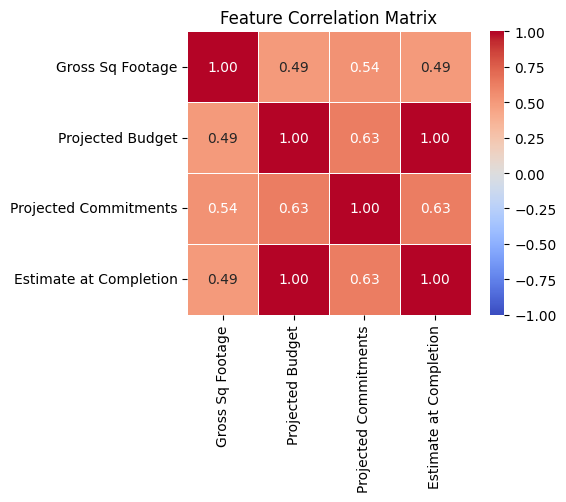

In [38]:
import seaborn as sns

feature_cols = ['Gross Sq Footage', 'Projected Budget', 'Projected Commitments', 'Estimate at Completion']

# Create feature inter-correlation matrix
corr = all_projects_df[feature_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


Estimate at Completion and Projected Budget show perfect correlation here, but they're not EXACTLY identical - only a small negligible difference. I'm choosing to leave them in with the thought that this nuance helps.

In [39]:
# Add new features EAC Budget Ratio and Commitments Budget Ratio (financial health independent of project size)
all_projects_df['EAC_Budget_Ratio'] = (all_projects_df['Estimate at Completion'] / all_projects_df['Projected Budget'].replace(0, np.nan))
all_projects_df['Commitments_Budget_Ratio'] = (all_projects_df['Projected Commitments'] / all_projects_df['Projected Budget'].replace(0, np.nan))

# Remove more NANs
mean_sq_footage = all_projects_df['Gross Sq Footage'].mean()
all_projects_df['Gross Sq Footage'] = all_projects_df['Gross Sq Footage'].fillna(mean_sq_footage)

# Budget density: $/sqft encodes project complexity/type (labs vs. parking vs. housing) without needing explicit building-type labels — this is a key signal for spend steepness (k)
all_projects_df['Budget_per_SqFt'] = (all_projects_df['Projected Budget'] / all_projects_df['Gross Sq Footage'].replace(0, np.nan))
budget_per_sqft_median = all_projects_df['Budget_per_SqFt'].median()
all_projects_df['Budget_per_SqFt'] = all_projects_df['Budget_per_SqFt'].fillna(budget_per_sqft_median)

# Log-transform skewed financial features
all_projects_df['Log_Projected_Budget'] = np.log1p(all_projects_df['Projected Budget'])
all_projects_df['Log_Gross_SqFt']       = np.log1p(all_projects_df['Gross Sq Footage'])

# Update feature list
feature_cols = ['Gross Sq Footage', 'Projected Budget', 'Projected Commitments', 'Estimate at Completion', 'EAC_Budget_Ratio', 'Commitments_Budget_Ratio', 'Budget_per_SqFt', 'Log_Projected_Budget', 'Log_Gross_SqFt']

""" FOR PRIVACY:

pd.set_option('display.max_rows', None)
display(all_projects_df[['Project Code'] + feature_cols].head(200))

"""

" FOR PRIVACY:\n\npd.set_option('display.max_rows', None)\ndisplay(all_projects_df[['Project Code'] + feature_cols].head(200))\n\n"

In [40]:
import warnings
from collections import Counter

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, KFold, RandomizedSearchCV, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [41]:
########################################################
"""

LOO CROSS-VALIDATION — Duration_Months, S_Curve_k (log-space), S_Curve_t0 (relative)


"""
########################################################

RANDOM_STATE = None

# Target definitions with transforms
_y_dur  = all_projects_df['Duration_Months']
_y_logk = np.log(all_projects_df['S_Curve_k'].replace(0, np.nan))
_y_t0r  = (all_projects_df['S_Curve_t0'] / all_projects_df['Duration_Months'].replace(0, np.nan))

targets = {'Duration_Months': _y_dur, 'S_Curve_k':  _y_logk, 'S_Curve_t0_rel':  _y_t0r}

# Model candidates with hyperparameter grids: RandomForest, GradientBoosting, XGBoost, LightGBM, Ridge, and ElasticNet
candidate_configs = [
    ('RF', RandomForestRegressor(random_state=RANDOM_STATE), {
        'n_estimators':    [100, 200, 300],
        'max_depth':       [3, 5, 10, None],
        'min_samples_leaf':[1, 2, 4],
        'max_features':    ['sqrt', 'log2'],
    }),
    ('GBR', GradientBoostingRegressor(random_state=RANDOM_STATE), {
        'n_estimators':    [100, 200, 300],
        'max_depth':       [2, 3, 4],
        'learning_rate':   [0.02, 0.05, 0.1],
        'min_samples_leaf':[1, 2, 4],
    }),
    ('XGB', XGBRegressor(random_state=RANDOM_STATE, verbosity=0), {
        'n_estimators':    [100, 200, 300],
        'max_depth':       [2, 3, 5],
        'learning_rate':   [0.02, 0.05, 0.1],
        'subsample':       [0.7, 1.0],
        'colsample_bytree':[0.7, 1.0],
    }),
    ('LGBM', LGBMRegressor(random_state=RANDOM_STATE, verbose=-1), {
        'n_estimators':    [100, 200, 300],
        'max_depth':       [3, 5, 7],
        'learning_rate':   [0.02, 0.05, 0.1],
        'num_leaves':      [15, 31, 63],
    }),
    ('Ridge', Pipeline([('scaler', StandardScaler()), ('model', Ridge())]), {
        'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
    }),
    ('ElasticNet', Pipeline([('scaler', StandardScaler()), ('model', ElasticNet(max_iter=5000))]), {
        'model__alpha':    [0.01, 0.1, 1.0, 10.0],
        'model__l1_ratio': [0.2, 0.5, 0.8],
    }),
]

loo = LeaveOneOut()
best_models  = {}
loo_predictions = {}

X_full = all_projects_df[feature_cols].values

for target_name, y_series in targets.items():
    print(f"\n{'='*60}")
    print(f"  TARGET: {target_name}")
    print(f"{'='*60}")

    # Drop some rows with NANs (simple safeguard)
    valid_mask = y_series.notna() & np.all(np.isfinite(X_full), axis=1)
    X = X_full[valid_mask]
    y = y_series.values[valid_mask]
    valid_indices = np.where(valid_mask)[0]
    n = len(y)
    print(f"  Valid samples: {n}")

    inner_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    best_r2 = -np.inf
    best_preds = None
    best_model = None
    best_name = None

    for name, estimator, param_grid in candidate_configs:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            # Tune hyperparameters once on full data
            gs = RandomizedSearchCV(estimator, param_grid, n_iter=15, cv=inner_cv, scoring='r2', random_state=RANDOM_STATE, n_jobs=-1)
            gs.fit(X, y)
            tuned_est = gs.best_estimator_

            # LOO out-of-fold evaluation
            y_pred = cross_val_predict(tuned_est, X, y, cv=loo, n_jobs=-1)

        r2 = r2_score(y, y_pred)
        rmse = np.sqrt(mean_squared_error(y, y_pred))
        print(f"  [{name}]  LOO R²={r2:.4f}  RMSE={rmse:.4f}")

        if r2 > best_r2:
            best_r2    = r2
            best_preds = y_pred
            best_model = tuned_est
            best_name  = name

    print(f"  → {best_name} wins  (LOO R²={best_r2:.4f})")
    loo_predictions[target_name] = (valid_indices, best_preds)
    best_models[target_name]     = best_model

# De-transform and rebuild full-length arrays
n_projects = len(all_projects_df)

# Duration (no transform needed)
dur_valid_idx, dur_preds = loo_predictions['Duration_Months']
full_dur_preds = np.full(n_projects, np.nan)
full_dur_preds[dur_valid_idx] = dur_preds

# k: exp(log_k) → k
k_valid_idx, log_k_preds = loo_predictions['S_Curve_k']
full_k_preds = np.full(n_projects, np.nan)
full_k_preds[k_valid_idx] = np.exp(log_k_preds)

# t0: t0_rel × Duration → t0 (absolute months)
t0_valid_idx, t0_rel_preds = loo_predictions['S_Curve_t0_rel']
full_t0_preds = np.full(n_projects, np.nan)
full_t0_preds[t0_valid_idx] = t0_rel_preds * full_dur_preds[t0_valid_idx]

# S_Curve_L: placeholder
full_L_preds = all_projects_df['Projected Commitments'].values.astype(float)

# Overwrite loo_predictions with full-length arrays
loo_predictions['Duration_Months'] = full_dur_preds
loo_predictions['S_Curve_k'] = full_k_preds
loo_predictions['S_Curve_t0'] = full_t0_preds
loo_predictions['S_Curve_L'] = full_L_preds

predictions1 = loo_predictions['Duration_Months']
predictions2 = loo_predictions['S_Curve_L']
predictions3 = loo_predictions['S_Curve_k']
predictions4 = loo_predictions['S_Curve_t0']


  TARGET: Duration_Months
  Valid samples: 204
  [RF]  LOO R²=0.4141  RMSE=19.4341
  [GBR]  LOO R²=0.4424  RMSE=18.9587
  [XGB]  LOO R²=0.4388  RMSE=19.0210


/Users/tomragus/Desktop/local/GitHub Projects/i4X-CPM-Model-Backend/i4x_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/tomragus/Desktop/local/GitHub Projects/i4X-CPM-Model-Backend/i4x_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/tomragus/Desktop/local/GitHub Projects/i4X-CPM-Model-Backend/i4x_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/tomragus/Desktop/local/GitHub Projects/i4X-CPM-Model-Backend/i4x_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  war

  [LGBM]  LOO R²=0.4078  RMSE=19.5389
  [Ridge]  LOO R²=0.4061  RMSE=19.5668
  [ElasticNet]  LOO R²=0.3979  RMSE=19.7020
  → GBR wins  (LOO R²=0.4424)

  TARGET: S_Curve_k
  Valid samples: 204
  [RF]  LOO R²=0.1312  RMSE=0.8252
  [GBR]  LOO R²=0.0734  RMSE=0.8522
  [XGB]  LOO R²=0.0758  RMSE=0.8511


/Users/tomragus/Desktop/local/GitHub Projects/i4X-CPM-Model-Backend/i4x_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/tomragus/Desktop/local/GitHub Projects/i4X-CPM-Model-Backend/i4x_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/tomragus/Desktop/local/GitHub Projects/i4X-CPM-Model-Backend/i4x_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/tomragus/Desktop/local/GitHub Projects/i4X-CPM-Model-Backend/i4x_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  war

  [LGBM]  LOO R²=0.0675  RMSE=0.8549
  [Ridge]  LOO R²=0.0801  RMSE=0.8491
  [ElasticNet]  LOO R²=0.0835  RMSE=0.8475
  → RF wins  (LOO R²=0.1312)

  TARGET: S_Curve_t0_rel
  Valid samples: 204
  [RF]  LOO R²=0.1739  RMSE=0.2198
  [GBR]  LOO R²=0.1379  RMSE=0.2246
  [XGB]  LOO R²=0.1577  RMSE=0.2220


/Users/tomragus/Desktop/local/GitHub Projects/i4X-CPM-Model-Backend/i4x_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/tomragus/Desktop/local/GitHub Projects/i4X-CPM-Model-Backend/i4x_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/tomragus/Desktop/local/GitHub Projects/i4X-CPM-Model-Backend/i4x_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/tomragus/Desktop/local/GitHub Projects/i4X-CPM-Model-Backend/i4x_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  war

  [LGBM]  LOO R²=0.1724  RMSE=0.2200
  [Ridge]  LOO R²=0.0683  RMSE=0.2334
  [ElasticNet]  LOO R²=0.0383  RMSE=0.2372
  → RF wins  (LOO R²=0.1739)


/Users/tomragus/Desktop/local/GitHub Projects/i4X-CPM-Model-Backend/i4x_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/tomragus/Desktop/local/GitHub Projects/i4X-CPM-Model-Backend/i4x_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/tomragus/Desktop/local/GitHub Projects/i4X-CPM-Model-Backend/i4x_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/tomragus/Desktop/local/GitHub Projects/i4X-CPM-Model-Backend/i4x_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  war

In [42]:
# Build predictions DataFrame
predictions_df = pd.DataFrame({
    "Project Code": all_projects_df['Project Code'].values,
    "Duration_Months": predictions1, "S_Curve_L": predictions2, "S_Curve_k": predictions3, "S_Curve_t0": predictions4
    })

# Replace "S_Curve_L" predictions with "Projected Commitments" data
predictions_df["S_Curve_L"] = all_projects_df["Projected Commitments"]
loo_predictions['S_Curve_L'] = predictions_df["S_Curve_L"]
predictions2 = loo_predictions['S_Curve_L']

""" FOR PRIVACY:

print("Predictions DataFrame (LOO out-of-fold, all projects):")
display(predictions_df)

"""

' FOR PRIVACY:\n\nprint("Predictions DataFrame (LOO out-of-fold, all projects):")\ndisplay(predictions_df)\n\n'

In [43]:
from matplotlib.ticker import MultipleLocator, FuncFormatter

# Currency formatter
def format_currency(x, pos):
    if x >= 1e6:
        return f'${x * 1e-6:.1f}M'
    elif x >= 1e3:
        return f'${x * 1e-3:.0f}K'
    else:
        return f'${x:,.0f}'

# Loop through and plot projects
for index, row in predictions_df.head(3).iterrows():
    L = row['S_Curve_L']
    k = row['S_Curve_k']
    t0 = row['S_Curve_t0']
    duration = row['Duration_Months']
    
    # Generate X axis
    x_data = np.arange(int(duration))
    predicted_y = logistic_curve(x_data, L, k, t0)
    

    """ FOR PRIVACY:
    # Plot the curve
    plt.figure(figsize=(9, 4))
    plt.plot(x_data, predicted_y, linewidth=3, color='#2ca02c', label="Parameterized S-Curve")
    plt.title(f"Standardized S-Curve: Project {row['Project Code']}", fontsize=14)
    plt.xlabel("Months from Project Start", fontsize=12) 
    plt.ylabel("Cumulative Cost", fontsize=12) # Removed ($) since the formatter adds it
    
    ax = plt.gca() 
    
    # X-Axis: Major ticks every 3 months, minor ticks every 1 month
    ax.xaxis.set_major_locator(MultipleLocator(3))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    
    # Y-Axis: Format as currency, create ~8 even major tick slices
    ax.yaxis.set_major_formatter(FuncFormatter(format_currency))
    ax.yaxis.set_major_locator(plt.MaxNLocator(8)) 
    ax.yaxis.set_minor_locator(plt.MaxNLocator(16)) 
    
    # Update grid to show both major (solid) and minor (dashed) lines
    plt.grid(which='major', color='#CCCCCC', linestyle='-', linewidth=0.8)
    plt.grid(which='minor', color='#EEEEEE', linestyle='--', linewidth=0.5)
    
    plt.legend()
    plt.tight_layout()
    plt.show()

    """

In [44]:
########################################################
"""

RECONSTRUCTION VALIDATION
Compare each project's predicted S-curve to its actual cumulative spend.
Uses LOO out-of-fold predictions — no data leakage.

"""
########################################################

from matplotlib.ticker import MultipleLocator, FuncFormatter

def format_currency(x, pos):
    if x >= 1e6:
        return f'${x * 1e-6:.1f}M'
    elif x >= 1e3:
        return f'${x * 1e-3:.0f}K'
    return f'${x:,.0f}'

timeline_dates_full = pd.date_range(start='2011-01-01', end='2027-06-01', freq='MS')
timeline_cols_full  = timeline_dates_full.strftime('%b %Y').tolist()

reconstruction_results = []

for idx, row in all_projects_df.iterrows():
    pc = row['Project Code']
    actual_row = all_projects_df_2[all_projects_df_2['Project Code'] == pc]
    if actual_row.empty:
        continue

    y_full    = actual_row[timeline_cols_full].values[0].astype(float)
    start_i   = np.argmax(y_full > 0)
    actual_dur = max(1, int(row['Duration_Months']))
    y_actual  = y_full[start_i : start_i + actual_dur]

    pred_dur = max(1, int(loo_predictions['Duration_Months'][idx]))
    pred_L   = loo_predictions['S_Curve_L'][idx]
    pred_k   = loo_predictions['S_Curve_k'][idx]
    pred_t0  = loo_predictions['S_Curve_t0'][idx]

    y_pred_curve = logistic_curve(np.arange(pred_dur), pred_L, pred_k, pred_t0)

    # Interpolate to common length for R^2 comparison
    n   = min(pred_dur, actual_dur)
    y_a = np.interp(np.linspace(0, 1, n), np.linspace(0, 1, actual_dur), y_actual)
    y_p = np.interp(np.linspace(0, 1, n), np.linspace(0, 1, pred_dur),   y_pred_curve)
    ss_tot   = np.sum((y_a - y_a.mean()) ** 2)
    curve_r2 = 1 - np.sum((y_a - y_p) ** 2) / ss_tot if ss_tot > 0 else np.nan
    reconstruction_results.append({'Project Code': pc, 'Curve_R2': curve_r2})

    """ FOR PRIVACY:

    # Plot predicted vs actual
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(np.arange(actual_dur), y_actual,    linewidth=2, color='#1f77b4', label="Actual", alpha=0.85)
    ax.plot(np.arange(pred_dur),   y_pred_curve, linewidth=2, color='#2ca02c', linestyle='--', label="Predicted S-Curve")
    ax.set_title(f"Predicted vs Actual: Project {pc}  (Curve R²={curve_r2:.3f})", fontsize=13)
    ax.set_xlabel("Months from Project Start", fontsize=11)
    ax.set_ylabel("Cumulative Cost", fontsize=11)
    ax.yaxis.set_major_formatter(FuncFormatter(format_currency))
    ax.xaxis.set_major_locator(MultipleLocator(3))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    plt.grid(which='major', color='#CCCCCC', linestyle='-',  linewidth=0.8)
    plt.grid(which='minor', color='#EEEEEE', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

    """

recon_df = pd.DataFrame(reconstruction_results)
print("\n=== RECONSTRUCTION SUMMARY ===")
print(recon_df.sort_values('Curve_R2').to_string(index=False))
print(f"\nMedian Curve R²: {recon_df['Curve_R2'].median():.4f}")
print(f"Projects with R² > 0.8: {(recon_df['Curve_R2'] > 0.8).sum()} / {len(recon_df)}")


=== RECONSTRUCTION SUMMARY ===
Project Code       Curve_R2
       C4116 -558387.289911
       C3665 -396905.939758
       C3994 -133909.144877
       C3689 -129473.999592
       C4219  -68850.647094
       C4149  -24820.992157
       C3993   -2305.161787
       C4218   -2161.182344
       C3808   -1099.228921
       C3874    -131.654073
       C4217     -27.830140
       C4461     -27.166606
       C5310     -27.013479
        5529     -25.634638
       C5556      -8.290671
        5530      -7.704584
       C4993      -7.501295
      CW4659      -7.344383
        5540      -6.610678
       C4456      -5.068518
        5558      -4.268225
       C5287      -3.802040
       C5344      -3.714800
       C5420      -3.270341
       C5327      -3.186312
       C5185      -2.743749
       C5395      -2.339283
       C4659      -2.081843
        5566      -2.069127
       C4345      -2.012867
        5148      -1.952113
       C4419      -1.852831
       C4315      -1.773049
        5734    

Some more testing: overall stats (Median R^2 and Proj's with R^2 > 0.8)

### Trial 1
**Median R^2:** 0.606

**Count R^2 > 0.8:** 68 / 204

### Trial 2
**Median R^2:** 0.6104

**Count R^2 > 0.8:** 66 / 204

### Trial 3
**Median R^2:** 0.6167

**Count R^2 > 0.8:** 63 / 204

### Trial 4
**Median R^2:** 0.6238

**Count R^2 > 0.8:** 65 / 204

### Trial 5
**Median R^2:** 0.6220

**Count R^2 > 0.8:** 60 / 204

In [45]:
# Export the models to "trained_models"
"""

import joblib
from pathlib import Path

output_dir = Path("trained_models")
output_dir.mkdir(exist_ok=True)
for target_name, model in best_models.items():
    file_path = output_dir / f"{target_name}_model_v2.joblib"
    joblib.dump(model, file_path)
    print(f"Success: Exported {target_name} model to {file_path}")
    
"""

'\n\nimport joblib\nfrom pathlib import Path\n\noutput_dir = Path("trained_models")\noutput_dir.mkdir(exist_ok=True)\nfor target_name, model in best_models.items():\n    file_path = output_dir / f"{target_name}_model_v2.joblib"\n    joblib.dump(model, file_path)\n    print(f"Success: Exported {target_name} model to {file_path}")\n    \n'